# ResNet-50 Baseline on RVL-CDIP Small-200

This notebook fine-tunes a ResNet-50 classifier head on the RVL-CDIP Small-200 dataset (16 document classes),
evaluates with accuracy, per-class metrics, and confusion matrix, then extracts and caches layer4 spatial features
for downstream GNN experiments.

**Outputs:**
- `checkpoints/resnet50_baseline_best.pt` — best model checkpoint
- `checkpoints/resnet50_baseline_metrics.json` — evaluation metrics
- `cached_features/{train,validation}/*.pt` — layer4 features per image

---

## 1. Setup

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
sys.path.insert(0, "..")

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

from src.config import Config
from src.data import load_rvl_cdip, get_transform, RVL_CDIP_LABELS
from src.features import (
    create_extractor_from_trained,
    extract_features_batch,
    cache_features,
    load_cached_features,
)

print(f"PyTorch: {torch.__version__}")

/Users/sagarpratapsingh/dev/sagerstack/deep-learning-doc-classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0


In [2]:
config = Config()
config.seed_everything()

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"\nConfiguration:")
print(f"  Device: {config.device}")
print(f"  Mode: {config.mode}")
print(f"  Batch size: {config.batch_size}")
print(f"  Cache dir: {config.cache_dir}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR.resolve()}")

Device: mps
Mode: sample
Sample size: 100

Configuration:
  Device: mps
  Mode: sample
  Batch size: 32
  Cache dir: cached_features
  Checkpoint dir: /Users/sagarpratapsingh/dev/sagerstack/deep-learning-doc-classification/checkpoints


## 2. Load Dataset

In [3]:
data = load_rvl_cdip(config)

print(f"\nDataset splits:")
for split_name, split_data in data.items():
    print(f"  {split_name}: {len(split_data)} samples")

print(f"\nClass labels ({len(RVL_CDIP_LABELS)} classes):")
for i, label in enumerate(RVL_CDIP_LABELS):
    print(f"  {i}: {label}")

Loading sample dataset: vaclavpechtor/rvl_cdip-small-200...


'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)' thrown while requesting HEAD https://huggingface.co/datasets/vaclavpechtor/rvl_cdip-small-200/resolve/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff/rvl_cdip-small-200.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since vaclavpechtor/rvl_cdip-small-200 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at .hf_cache/vaclavpechtor___rvl_cdip-small-200/default/0.0.0/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff (last modified on Wed Mar 25 21:56:37 2026).


Loaded train: 2560 samples
Loaded validation: 640 samples

Dataset splits:
  train: 2560 samples
  validation: 640 samples

Class labels (16 classes):
  0: advertisement
  1: budget
  2: email
  3: file_folder
  4: form
  5: handwritten
  6: invoice
  7: letter
  8: memo
  9: news_article
  10: presentation
  11: questionnaire
  12: resume
  13: scientific_publication
  14: scientific_report
  15: specification


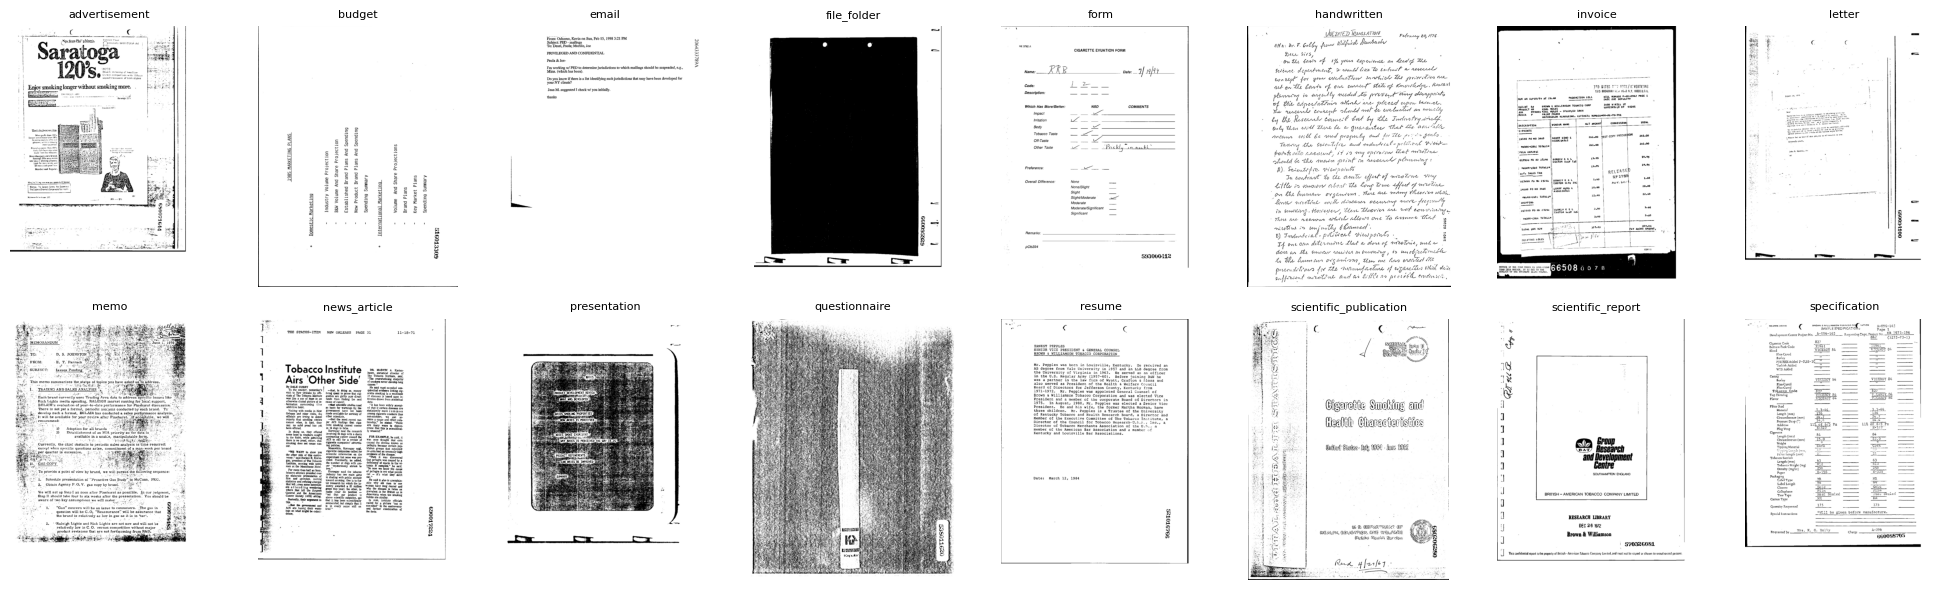

In [4]:
# Display one sample per class (2x8 grid)
seen_labels = set()
class_samples = []
for sample in data["train"]:
    if sample["label"] not in seen_labels:
        class_samples.append(sample)
        seen_labels.add(sample["label"])
    if len(seen_labels) == len(RVL_CDIP_LABELS):
        break

class_samples.sort(key=lambda s: s["label"])

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
axes = axes.flatten()

for i, sample in enumerate(class_samples):
    axes[i].imshow(sample["image"], cmap="gray")
    axes[i].set_title(RVL_CDIP_LABELS[sample["label"]], fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3. DataLoader Setup

In [5]:
transform = get_transform()


class RvlCdipDataset(Dataset):
    """Wraps RVL-CDIP samples for PyTorch DataLoader."""

    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = self.transform(sample["image"])
        label = sample["label"]
        return image, label


train_dataset = RvlCdipDataset(data["train"], transform)
val_dataset = RvlCdipDataset(data["validation"], transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")

Train: 2560 samples, 80 batches
Val:   640 samples, 20 batches


## 4. ResNet-50 Classifier

Unfreeze layer3 + layer4 + FC head with differential learning rates (following the reference notebook's Stage 3 strategy).
Deeper layers get lower LR to preserve pretrained representations while adapting to document domain.

In [6]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Freeze entire backbone first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 + layer4 + new fc head
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_classes = len(RVL_CDIP_LABELS)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(config.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:>12,}")
print(f"Trainable parameters: {trainable_params:>12,}  (layer3 + layer4 + fc)")
print(f"Frozen parameters:    {frozen_params:>12,}  (conv1 + bn1 + layer1 + layer2)")

Total parameters:       23,540,816
Trainable parameters:   22,095,888  (layer3 + layer4 + fc)
Frozen parameters:       1,444,928  (conv1 + bn1 + layer1 + layer2)


## 5. Training

In [7]:
NUM_EPOCHS = 25
LR_LAYER3 = 1e-5
LR_LAYER4 = 1e-4
LR_FC = 1e-3
LR_STEP_SIZE = 3
LR_GAMMA = 0.1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {"params": model.layer3.parameters(), "lr": LR_LAYER3},
    {"params": model.layer4.parameters(), "lr": LR_LAYER4},
    {"params": model.fc.parameters(), "lr": LR_FC},
])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

print(f"Epochs: {NUM_EPOCHS}")
print(f"Optimizer: Adam (differential LR)")
print(f"  layer3: {LR_LAYER3}")
print(f"  layer4: {LR_LAYER4}")
print(f"  fc:     {LR_FC}")
print(f"Scheduler: StepLR (step={LR_STEP_SIZE}, gamma={LR_GAMMA})")
print(f"Loss: CrossEntropyLoss")

Epochs: 25
Optimizer: Adam (differential LR)
  layer3: 1e-05
  layer4: 0.0001
  fc:     0.001
Scheduler: StepLR (step=3, gamma=0.1)
Loss: CrossEntropyLoss


In [8]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_checkpoint_path = CHECKPOINT_DIR / "resnet50_baseline_best.pt"

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(config.device), labels.to(config.device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_total += images.size(0)

    scheduler.step()

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # --- Validate ---
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(config.device), labels.to(config.device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += images.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    checkpoint_marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_checkpoint_path)
        checkpoint_marker = " *"

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{checkpoint_marker}"
    )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Checkpoint saved to: {best_checkpoint_path}")

Epoch 01/25 | Train Loss: 1.9854  Acc: 0.4098 | Val Loss: 1.5563  Acc: 0.5437 *
Epoch 02/25 | Train Loss: 1.1290  Acc: 0.6613 | Val Loss: 1.3971  Acc: 0.5906 *
Epoch 03/25 | Train Loss: 0.6878  Acc: 0.7941 | Val Loss: 1.3961  Acc: 0.5828
Epoch 04/25 | Train Loss: 0.3779  Acc: 0.9105 | Val Loss: 1.3726  Acc: 0.6125 *
Epoch 05/25 | Train Loss: 0.3564  Acc: 0.9125 | Val Loss: 1.3828  Acc: 0.6219 *
Epoch 06/25 | Train Loss: 0.2978  Acc: 0.9340 | Val Loss: 1.3848  Acc: 0.6172
Epoch 07/25 | Train Loss: 0.2803  Acc: 0.9371 | Val Loss: 1.3852  Acc: 0.6234 *
Epoch 08/25 | Train Loss: 0.2700  Acc: 0.9391 | Val Loss: 1.3793  Acc: 0.6312 *
Epoch 09/25 | Train Loss: 0.2881  Acc: 0.9340 | Val Loss: 1.3740  Acc: 0.6359 *
Epoch 10/25 | Train Loss: 0.2771  Acc: 0.9363 | Val Loss: 1.3778  Acc: 0.6172
Epoch 11/25 | Train Loss: 0.2659  Acc: 0.9398 | Val Loss: 1.3622  Acc: 0.6297
Epoch 12/25 | Train Loss: 0.2736  Acc: 0.9383 | Val Loss: 1.3979  Acc: 0.6328
Epoch 13/25 | Train Loss: 0.2461  Acc: 0.9437 | Va

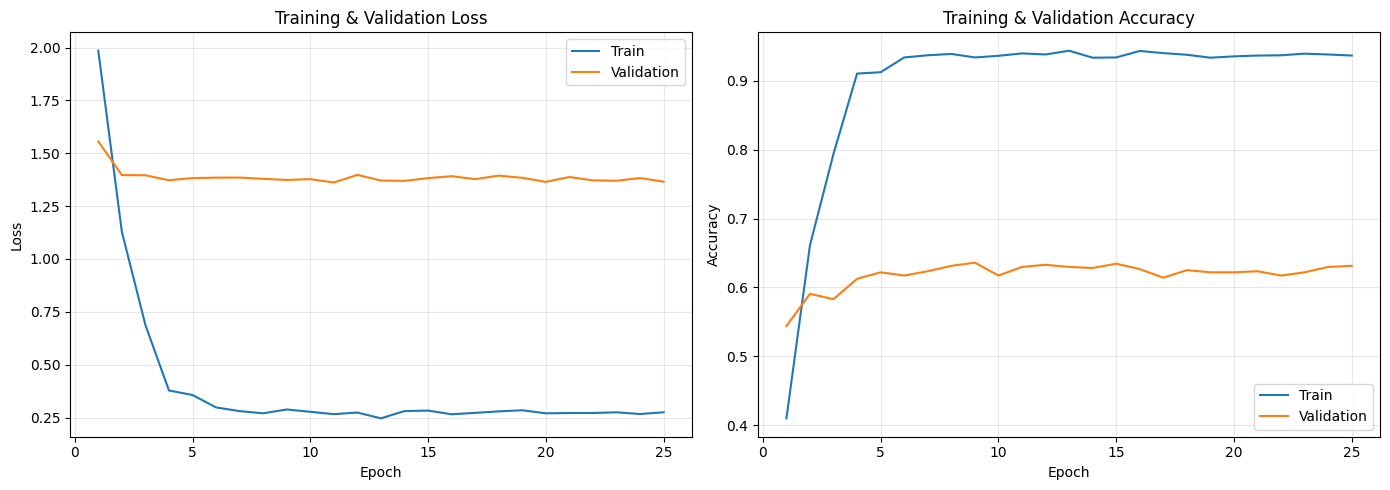

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["val_loss"], label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["val_acc"], label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

In [10]:
# Load best checkpoint and collect predictions on validation set
model.load_state_dict(torch.load(best_checkpoint_path, weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(config.device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

val_accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Validation accuracy (best checkpoint): {val_accuracy:.4f}")

Validation accuracy (best checkpoint): 0.6359


In [11]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=RVL_CDIP_LABELS,
    digits=4,
)
print(report)

                        precision    recall  f1-score   support

         advertisement     0.6818    0.7500    0.7143        40
                budget     0.5094    0.6750    0.5806        40
                 email     0.7727    0.8500    0.8095        40
           file_folder     0.8293    0.8500    0.8395        40
                  form     0.5161    0.4000    0.4507        40
           handwritten     0.7857    0.8250    0.8049        40
               invoice     0.5806    0.4500    0.5070        40
                letter     0.5435    0.6250    0.5814        40
                  memo     0.5135    0.4750    0.4935        40
          news_article     0.7667    0.5750    0.6571        40
          presentation     0.6000    0.6000    0.6000        40
         questionnaire     0.5385    0.5250    0.5316        40
                resume     0.8571    0.9000    0.8780        40
scientific_publication     0.7105    0.6750    0.6923        40
     scientific_report     0.4286    0.

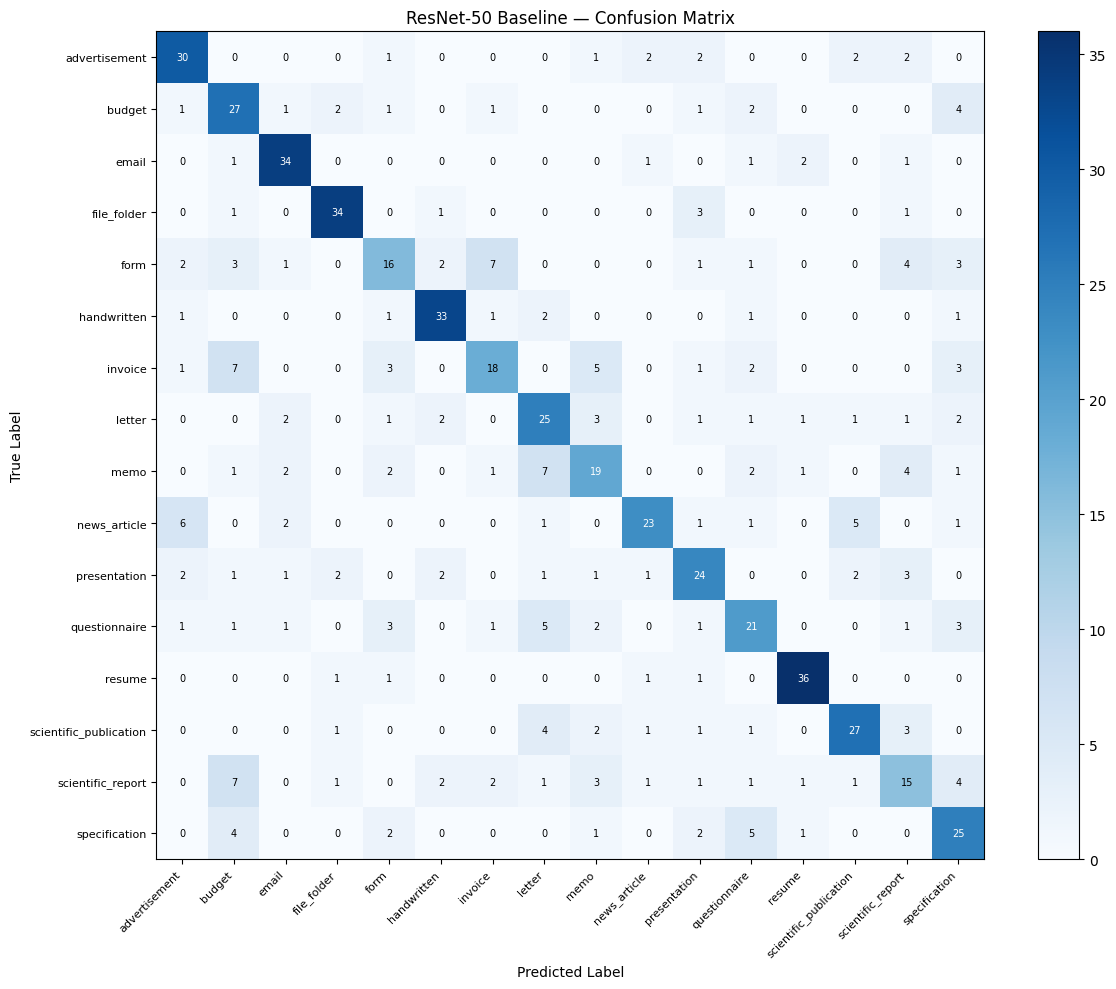

In [12]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("ResNet-50 Baseline — Confusion Matrix")
plt.colorbar(im, ax=ax, fraction=0.046)

tick_marks = np.arange(len(RVL_CDIP_LABELS))
ax.set_xticks(tick_marks)
ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(tick_marks)
ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=8)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=7,
        )

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 7. Feature Extraction & Caching

Extract layer4 spatial features `[2048, 7, 7]` and cache to disk for GNN experiments.

In [13]:
extractor = create_extractor_from_trained(model, config)

for split_name in data.keys():
    print(f"\nCaching {split_name} split...")
    cache_dir = cache_features(
        data[split_name],
        extractor,
        transform,
        config,
        split_name,
    )
    print(f"Cached to: {cache_dir}")

Fine-tuned feature extractor loaded
Parameters: 23,508,032 (all frozen for extraction)
Output: layer4 [B, 2048, 7, 7] + avgpool [B, 2048, 1, 1]
Device: mps

Caching train split...
Caching 2560 samples to cached_features/train...


100%|██████████| 80/80 [01:57<00:00,  1.47s/it]


Cached 2560 features to cached_features/train
Cached to: cached_features/train

Caching validation split...
Caching 640 samples to cached_features/validation...


100%|██████████| 20/20 [00:23<00:00,  1.18s/it]

Cached 640 features to cached_features/validation
Cached to: cached_features/validation


## 7.1 Text Density Cache Augmentation

Augment cached features with text density from doctr DBNet detector. This adds a `text_density` [7,7] tensor to each cached .pt file without re-running ResNet-50 feature extraction. Existing keys (features, global_feat, label) are preserved.

**Prerequisites:** Run cells C1-C4 (setup, data loading) and Section 7 (feature caching) first.
**Skips:** Files that already have `text_density` key.

In [ ]:
# C20: Text density cache augmentation
import torch
from src.text_features import create_text_detector, augment_cache_with_text_density

text_detector = create_text_detector(config)

# Augment each split's cache with text density
for split_name in data.keys():
    print(f"\nAugmenting {split_name} cache with text density...")
    augment_cache_with_text_density(
        config=config,
        split=split_name,
        detector=text_detector,
        samples=data[split_name],  # list of dicts with "image" key (PIL Image)
    )

# Verify: load one file and check text_density key exists
sample_path = list((config.cache_dir / "train").glob("*.pt"))[0]
sample = torch.load(sample_path, weights_only=False)
print(f"\nVerification - cached keys: {list(sample.keys())}")
print(f"text_density shape: {sample['text_density'].shape}")

## 8. Save Baseline Metrics

Save metrics to JSON for cross-notebook comparison with GNN models.

In [ ]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=RVL_CDIP_LABELS,
    output_dict=True,
)

metrics = {
    "model": "resnet50_baseline",
    "accuracy": val_accuracy,
    "per_class": {
        label: {
            "precision": report_dict[label]["precision"],
            "recall": report_dict[label]["recall"],
            "f1": report_dict[label]["f1-score"],
            "support": report_dict[label]["support"],
        }
        for label in RVL_CDIP_LABELS
    },
    "macro_avg": {
        "precision": report_dict["macro avg"]["precision"],
        "recall": report_dict["macro avg"]["recall"],
        "f1": report_dict["macro avg"]["f1-score"],
    },
    "confusion_matrix": cm.tolist(),
    "history": history,
}

metrics_path = CHECKPOINT_DIR / "resnet50_baseline_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to: {metrics_path}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Macro F1: {metrics['macro_avg']['f1']:.4f}")